In [1]:
import sys

In [2]:
%%capture
try:
    # Attempt to import a module that's only available in Colab
    from google.colab import drive

    in_colab = True
except ImportError:
    in_colab = False

if in_colab:
    # Colab specific setup
    drive.mount("/content/drive")
    sys.path.append("/content/drive/MyDrive/structure-loss-classification/")
    my_local_data = "/content/drive/MyDrive/types/"
    %cd '/content/drive/MyDrive/structure-loss-classification/'
    %pip install -r requirements.txt
else:
    # Local machine setup
    my_local_data = "/mnt/g/My Drive/types/"

In [3]:
import torch
import torch.nn as nn

import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision.models.feature_extraction import (
    get_graph_node_names,
    create_feature_extractor,
)

In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay

In [6]:
import pytorch_lightning as pl

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pandas as pd

plt.style.use(["science", "notebook", "grid"])

In [8]:
import pickle

In [9]:
from models.models import LeNet5
from lightning_modules.lightning_modules import LitLeNet5
from visualization.filters import display_filters
from visualization.display import process_plot_image
from datasets.data_modules import CustomImageDataModule
from train.train import get_features, train_model, train_with_cv
from hyperparameter_tuning.tune import HyperParameterTuner
from datasets.datasets import CustomDatasetWrapper

In [10]:
toTensorAndNormalize = transforms.Compose(
    [
        transforms.Resize((244, 244)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # mean  # std
    ]
)

In [11]:
from ray import tune

In [12]:
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset

In [13]:
classification_mode="binary"

In [14]:
task = {
    'binary': 2,
    'only_bad': 3,
    'all': 4
}

In [15]:
num_classes = task[classification_mode]

In [16]:
aux_data = CustomDatasetWrapper(
    root_dir=my_local_data,
    classification_mode=classification_mode,
    transform=toTensorAndNormalize,
)

In [17]:
# Try to load cached targets first
try:
    with open(f"logdir/cached_targets_{aux_data.classification_mode}.pkl", "rb") as f:
        targets = pickle.load(f)
except FileNotFoundError:
    targets = [t for _, t in aux_data]
    # Cache the targets for next time
    with open(f"logdir/cached_targets_{aux_data.classification_mode}.pkl", "wb") as f:
        pickle.dump(targets, f)

In [18]:
model = LitLeNet5(num_classes=num_classes, learning_rate=0.005)

In [19]:
trainer_config = {
    "patience": 50,
    "accelerator": "gpu",
    "devices": -1,
    "max_epochs": 200,
    "precision": 32,
    "n_steps": 5,
}

In [20]:
# Assuming aux_data is a dataset object and targets are the labels
train_idx, val_idx, _, _ = train_test_split(
    range(len(aux_data)), targets, test_size=0.2, random_state=42
)

train_data = torch.utils.data.Subset(aux_data, train_idx)
val_data = torch.utils.data.Subset(aux_data, val_idx)

In [21]:
data_module = CustomImageDataModule(
    train_dataset=train_data,
    val_dataset=val_data,
    batch_size=32,
    num_workers=12,
)

### Test train

In [22]:
torch.set_float32_matmul_precision('medium')

In [23]:
# %%capture
# val_metrics, cm = train_model(
#     model=model,
#     trainer_config=trainer_config,
#     save_dir="logdir/",
#     data_module=data_module,
# )

In [24]:
# cm

In [25]:
# val_metrics

In [26]:
# df = pd.read_csv('logdir/LitLeNet5/lightning_logs/version_15/metrics.csv')

In [27]:
# df.plot(kind='line',x='epoch',y=['val_loss', 'val_accuracy'])

In [28]:
# ConfusionMatrixDisplay(np.array(cm)).plot()

## Hyperparameter Tuning

In [29]:
default_config = {
    "layer_1_size": 128,
    "layer_2_size": 256,
    "lr": 1e-3,
    "batch_size": 16
}

In [30]:
search_space = {
    "layer_1_size": tune.choice([64, 84, 128]),
    "layer_2_size": tune.choice([16, 32, 64]),
    "lr": tune.loguniform(1e-5, 1e-2),
    "batch_size": tune.choice([16, 32, 64]),
}

In [31]:
# The maximum training epochs
num_epochs = 10

# Number of sampls from parameter space
num_samples = 10

In [32]:
tuner = HyperParameterTuner(model=model,
                            datamodule=data_module,
                            search_space=search_space,
                            num_epochs=num_epochs,
                            num_samples=num_samples
                            )

In [33]:
torch.set_float32_matmul_precision('medium')

In [34]:
%%capture
# test_config = tuner.hypertune()

In [35]:
# test_config = test_config['train_loop_config']

In [36]:
# test_config

In [37]:
test_config = {'layer_1_size': 128,
 'layer_2_size': 64,
 'lr': 8.479282111072422e-05,
 'batch_size': 16}

In [38]:
tuned_model = LitLeNet5(
                        num_classes = num_classes,
                        learning_rate = test_config['lr'],
                        size_layer_1 = test_config['layer_1_size'],
                        size_layer_2 = test_config['layer_2_size'],
                        )

In [39]:
model_params = {'num_classes' : num_classes,
                        'learning_rate' : test_config['lr'],
                        'size_layer_1' : test_config['layer_1_size'],
                        'size_layer_2' : test_config['layer_2_size']}

In [40]:
test_123 = LitLeNet5(**model_params)

In [41]:
test_123.size_layer_1

128

In [42]:
tuned_data_module = CustomImageDataModule(
                                        train_dataset=train_data,
                                        val_dataset=val_data,
                                        batch_size=test_config['batch_size'],
                                        num_workers=4,
                                        )

In [43]:
classification_mode

'binary'

In [44]:
train_with_cv

<function train.train.train_with_cv(model: pytorch_lightning.core.module.LightningModule, model_params: dict, trainer_config: dict, data: datasets.datasets.CustomDatasetWrapper, targets: list, classification_mode: str, save_dir_base: str = None, n_splits: int = 5, shuffle: bool = True, batch_size: int = 16, num_workers: int = 12, random_state: int = 42) -> dict>

In [ ]:
all_metrics, confusion_matrices = train_with_cv(model = LitLeNet5,
                                                model_params = model_params,
                                                trainer_config=trainer_config,
                                                data=aux_data,
                                                targets=targets,
                                                classification_mode=classification_mode
                                                )

Starting Fold 1/5


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name     | Type                      | Params
-------------------------------------------------------
0 | accuracy | MulticlassAccuracy        | 0     
1 | f1_score | MulticlassF1Score         | 0     
2 | cm       | MulticlassConfusionMatrix | 0     
3 | loss_fn  | CrossEntropyLoss          | 0     
4 | model    | LeNet5                    | 44.8 M
-------------------------------------------------------
44.8 M    Trainable params
0         Non-trainable params
44.8 M    Total params
179.398   Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Validation Confusion Matrix: tensor([[14,  0],
        [18,  0]], device='cuda:0')


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation Confusion Matrix: tensor([[ 38,  28],
        [ 22, 167]], device='cuda:0')


Validation: |          | 0/? [00:00<?, ?it/s]

Validation Confusion Matrix: tensor([[ 40,  26],
        [ 13, 176]], device='cuda:0')


Validation: |          | 0/? [00:00<?, ?it/s]

Validation Confusion Matrix: tensor([[ 37,  29],
        [ 24, 165]], device='cuda:0')


In [ ]:
from visualization.display import display_metrics

In [ ]:
display_metrics(version=0, model=tuned_model, classification_mode=classification_mode)

In [44]:
all_metrics

[({'val_loss': 0.3967990577220917,
   'val_accuracy': 0.9019607901573181,
   'val_f1_score': 0.9019607901573181},
  array([[ 9,  5],
         [ 0, 37]])),
 ({'val_loss': 0.21361973881721497,
   'val_accuracy': 0.9411764740943909,
   'val_f1_score': 0.9411764740943909},
  array([[11,  2],
         [ 1, 37]])),
 ({'val_loss': 0.0010767680360004306,
   'val_accuracy': 1.0,
   'val_f1_score': 1.0},
  array([[13,  0],
         [ 0, 38]])),
 ({'val_loss': 0.012128787115216255, 'val_accuracy': 1.0, 'val_f1_score': 1.0},
  array([[13,  0],
         [ 0, 38]])),
 ({'val_loss': 0.00010831585677806288,
   'val_accuracy': 1.0,
   'val_f1_score': 1.0},
  array([[13,  0],
         [ 0, 38]]))]

In [135]:
cm = np.array([all_metrics[i][1] for i in range(len(all_metrics))])

In [143]:
cm.mean(axis=0)

array([[11.8,  1.4],
       [ 0.2, 37.6]])

In [45]:
df1 = pd.read_csv('logdir/LitLeNet5/cv/fold_1/LitLeNet5/lightning_logs/version_0/metrics.csv')
df2 = pd.read_csv('logdir/LitLeNet5/cv/fold_2/LitLeNet5/lightning_logs/version_0/metrics.csv')
df3 = pd.read_csv('logdir/LitLeNet5/cv/fold_3/LitLeNet5/lightning_logs/version_0/metrics.csv')
df4 = pd.read_csv('logdir/LitLeNet5/cv/fold_4/LitLeNet5/lightning_logs/version_0/metrics.csv')
df5 = pd.read_csv('logdir/LitLeNet5/cv/fold_5/LitLeNet5/lightning_logs/version_0/metrics.csv')

In [154]:
import os

In [155]:
len(os.listdir('logdir/LitLeNet5/cv/'))

5

In [109]:
dfs = [df1, df2, df3, df4, df5]

min_length = min(df.shape[0] for df in dfs)

dfs = [df1.iloc[:min_length], df2.iloc[:min_length], df3.iloc[:min_length], df4.iloc[:min_length], df5.iloc[:min_length]]

all_folds = pd.concat(dfs, ignore_index=True)


In [110]:
grouped = all_folds.groupby('epoch').agg({
    'val_accuracy': ['mean', 'std'],
    'val_loss': ['mean', 'std']
}).reset_index()

In [111]:
grouped.columns = ['epoch', 'mean_val_accuracy', 'std_val_accuracy', 'mean_val_loss', 'std_val_loss']

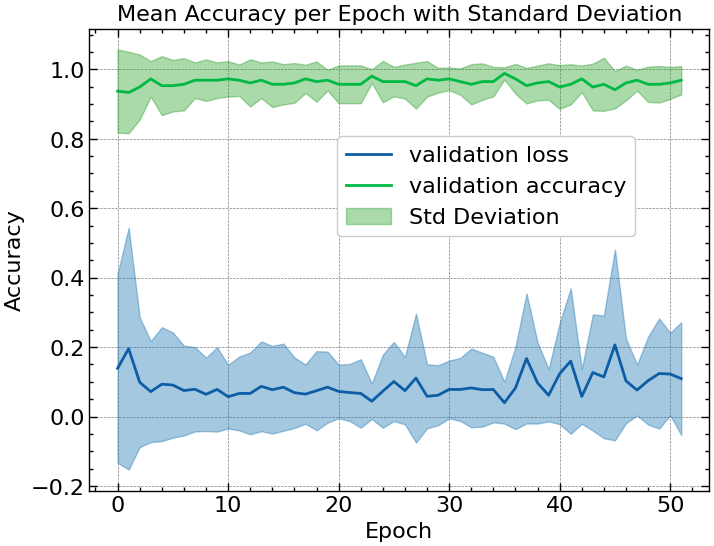

In [147]:
plt.plot(grouped.epoch, grouped.mean_val_loss, label='validation loss')
plt.fill_between(grouped.epoch, grouped.mean_val_loss+grouped.std_val_loss, grouped.mean_val_loss-grouped.std_val_loss, color='tab:blue', alpha=0.4)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Mean Accuracy per Epoch with Standard Deviation')
plt.legend()
plt.grid(True)
plt.plot(grouped.epoch, grouped.mean_val_accuracy, label='validation accuracy')
plt.fill_between(grouped.epoch, grouped.mean_val_accuracy+grouped.std_val_accuracy, grouped.mean_val_accuracy-grouped.std_val_accuracy, color='tab:green', alpha=0.4,label='Std Deviation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Mean Accuracy per Epoch with Standard Deviation')
plt.legend(loc=(0.4, 0.55))
plt.grid(True)
plt.show()

### Re-trained after tuning

In [ ]:
%%capture
val_metrics, cm= train_model(
    model=tuned_model,
    trainer_config=trainer_config,
    save_dir="logdir/",
    data_module=tuned_data_module,
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name     | Type                      | Params
-------------------------------------------------------
0 | accuracy | MulticlassAccuracy        | 0     
1 | f1_score | MulticlassF1Score         | 0     
2 | cm       | MulticlassConfusionMatrix | 0     
3 | loss_fn  | CrossEntropyLoss          | 0     
4 | model    | LeNet5                    | 44.8 M
-------------------------------------------------------
44.8 M    Trainable params
0         Non-trainable params
44.8 M    Total params
179.398   Total estimated model params size (MB)
INF

In [ ]:
df = pd.read_csv('logdir/LitLeNet5/lightning_logs/version_18/metrics.csv')

In [ ]:
[df.val_loss]

[0     0.500559
 1     0.820274
 2     0.447448
 3     0.353654
 4     0.355966
         ...   
 74    0.410201
 75    0.170178
 76    0.324119
 77    0.365883
 78    0.333532
 Name: val_loss, Length: 79, dtype: float64]

<Axes: xlabel='epoch'>

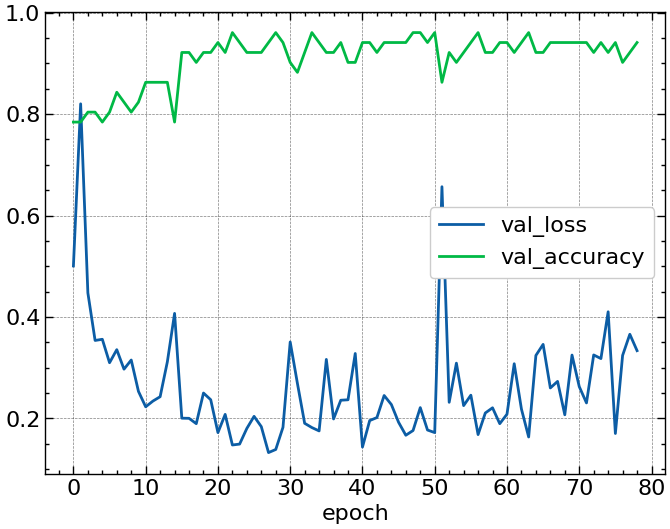

In [ ]:
df.plot(kind='line',x='epoch',y=['val_loss', 'val_accuracy'])

In [ ]:
val_metrics

{'val_loss': 0.3335323631763458,
 'val_accuracy': 0.9411764740943909,
 'val_f1_score': 0.9411764740943909}

In [ ]:
cm

array([[12,  0],
       [ 3, 36]])

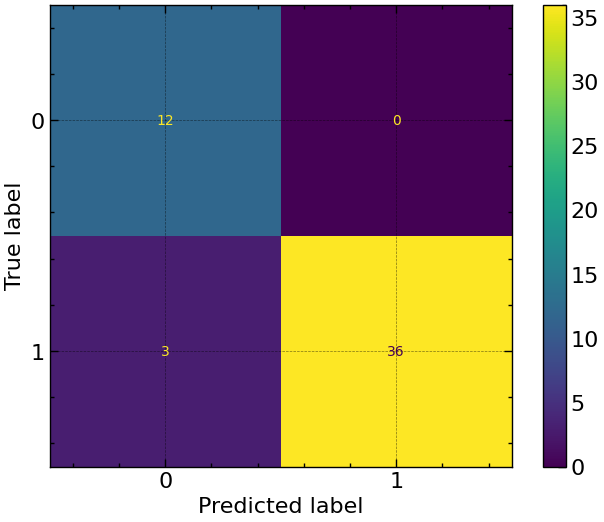

In [ ]:
ConfusionMatrixDisplay(np.array(cm)).plot()

In [ ]:
max(df.val_accuracy)

0.9607843160629272